In [53]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
from scipy.stats import pearsonr
from scipy.stats import sem
from scipy.stats import ttest_rel
import os
from statsmodels.stats.anova import AnovaRM


In [2]:
metrics = ['random','variance','log_det_mc','inverse_trace_mc']

custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

# parcellation simulation

In [3]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]

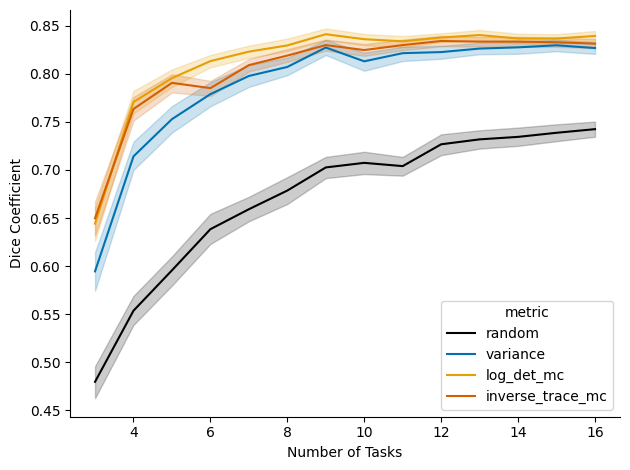

In [4]:
sns.lineplot(
    data=D,
    x="n_task",
    y="accuracy",
    hue="metric",
    palette=custom_palette,

)

plt.xlabel("Number of Tasks")
plt.ylabel("Dice Coefficient")
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_parcellate.pdf", format="pdf", bbox_inches="tight")
plt.show()

# connectivity simulation

In [68]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'connectivity_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]

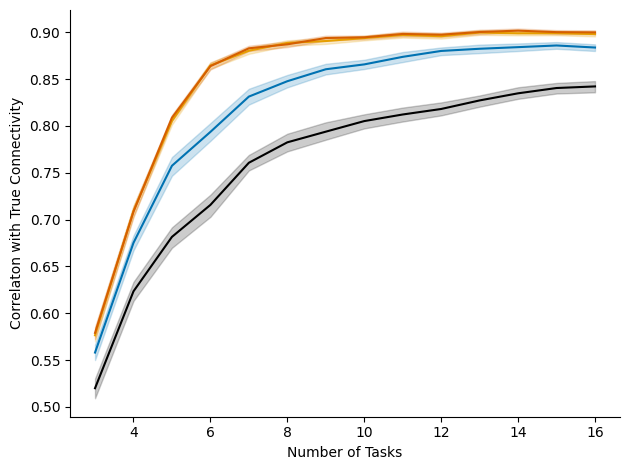

In [69]:
sns.lineplot(
    data=D,
    x="n_task",
    y="correlation",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("Correlaton with True Connectivity")
plt.legend([],[], frameon=False)
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

# parcellation real (cortex)

In [58]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_real_cortex.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D = D[D['roi']=='All Parcels']

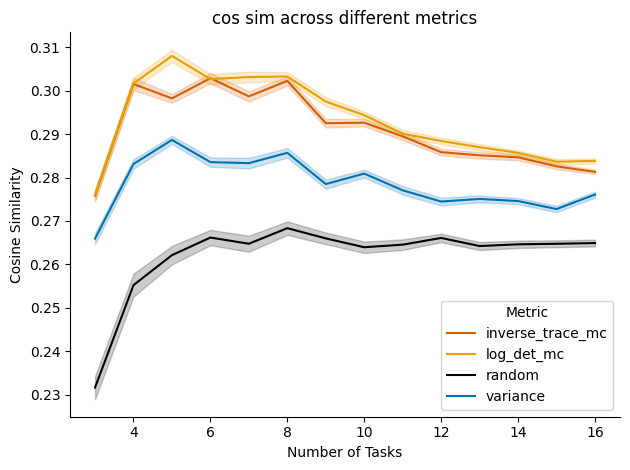

In [59]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_cos_sim_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_cortical_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [60]:
avg_df = D.groupby(['sub', 'metric'], as_index=False)['avg_cos_sim_per_subject'].mean()
it = avg_df[avg_df.metric == 'inverse_trace_mc']['avg_cos_sim_per_subject'].values
v = avg_df[avg_df.metric == 'variance']['avg_cos_sim_per_subject'].values
lg = avg_df[avg_df.metric == 'log_det_mc']['avg_cos_sim_per_subject'].values
rand = avg_df[avg_df.metric == 'random']['avg_cos_sim_per_subject'].values


t, p = ttest_rel(v, rand)
print(t,p)
t, p = ttest_rel(lg, rand)
print(t,p)
t, p = ttest_rel(it, rand)
print(t,p)

10.544947383208699 2.7830610159325377e-10
14.229129019780748 6.873201124373677e-13
13.861876040453824 1.1807486998565476e-12


In [61]:
t, p = ttest_rel(lg, v)
print(t,p)
t, p = ttest_rel(it, v)
print(t,p)

10.95147874562067 1.3395494291238136e-10
9.360118675698484 2.6222427368702294e-09


In [63]:
D

,n_task,metric,roi,avg_cos_sim_per_subject,sub,adjusted
0,3,inverse_trace_mc,All Parcels,0.264814,1,0.266094
1,3,inverse_trace_mc,All Parcels,0.290749,2,0.272558
2,3,inverse_trace_mc,All Parcels,0.176568,3,0.272936
3,3,inverse_trace_mc,All Parcels,0.358443,4,0.277968
4,3,inverse_trace_mc,All Parcels,0.233144,5,0.276079
...,...,...,...,...,...,...
1651,16,variance,All Parcels,0.313291,20,0.279778
1652,16,variance,All Parcels,0.310953,21,0.280932
1653,16,variance,All Parcels,0.224182,22,0.270767
1654,16,variance,All Parcels,0.165765,23,0.277621


In [64]:
dd_df = (
    D[D.metric.isin(['variance', 'log_det_mc', 'inverse_trace_mc'])]
    .groupby(['sub', 'n_task'])['avg_cos_sim_per_subject']
    .mean()
    .reset_index()
)

dd_df['selection'] = 'data_driven'


rand_df = D[D.metric == 'random'][['sub', 'n_task', 'avg_cos_sim_per_subject']].copy()
rand_df['selection'] = 'random'


anova_df = pd.concat([dd_df, rand_df], ignore_index=True)

aov = AnovaRM(
    anova_df,
    depvar='avg_cos_sim_per_subject',
    subject='sub',
    within=['selection', 'n_task']
)

res = aov.fit()
print(res)

                      Anova
                 F Value   Num DF  Den DF  Pr > F
-------------------------------------------------
selection        187.9978  1.0000  23.0000 0.0000
n_task            60.4550 13.0000 299.0000 0.0000
selection:n_task  66.8568 13.0000 299.0000 0.0000



# parcellation real (cerebellum)

In [43]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'connectivity_real_1t2_10000.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
# D = D[D['roi']=='all']


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\barafat\\Documents\\GitHub\\OptimalBattery\\eval_tsvs\\connectivity_real_1t2_10000.tsv'

In [44]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_cerebellar_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

KeyError: 'Column not found: avg_correlation_per_subject'

# connectivity real

In [81]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_connectivity_org.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

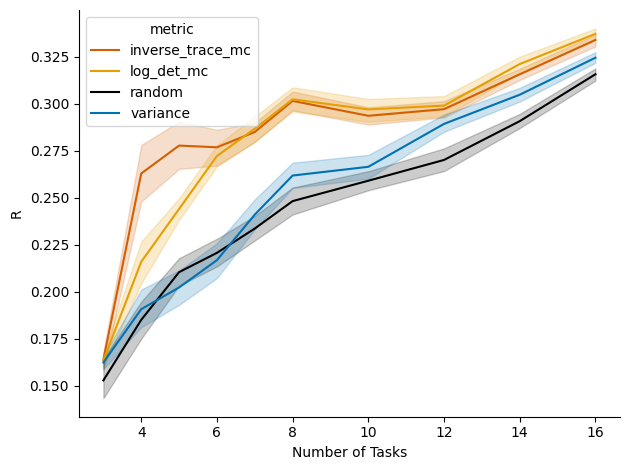

In [82]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("R")
# remove legend 
plt.tight_layout()
sns.despine()
plt.savefig(f"{save_dir}/battery_criteria/real_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [83]:
avg_df = D.groupby(['sub', 'metric'], as_index=False)['avg_correlation_per_subject'].mean()
it = avg_df[avg_df.metric == 'inverse_trace_mc']['avg_correlation_per_subject'].values
v = avg_df[avg_df.metric == 'variance']['avg_correlation_per_subject'].values
lg = avg_df[avg_df.metric == 'log_det_mc']['avg_correlation_per_subject'].values
rand = avg_df[avg_df.metric == 'random']['avg_correlation_per_subject'].values


t, p = ttest_rel(v, rand)
print(t,p)
t, p = ttest_rel(lg, rand)
print(t,p)
t, p = ttest_rel(it, rand)
print(t,p)


2.076607855110563 0.049196127019814045
7.9558448233964585 4.715826339144636e-08
8.13651397669789 3.204554825340062e-08


In [84]:
t, p = ttest_rel(lg, v)
print(t,p)
t, p = ttest_rel(it, v)
print(t,p)


6.864906457979926 5.330031115538351e-07
6.942192706261965 4.4657509005683877e-07


In [85]:
dd_df = (
    D[D.metric.isin(['variance', 'log_det_mc', 'inverse_trace_mc'])]
    .groupby(['sub', 'n_task'])['avg_correlation_per_subject']
    .mean()
    .reset_index()
)

dd_df['selection'] = 'data_driven'


rand_df = D[D.metric == 'random'][['sub', 'n_task', 'avg_correlation_per_subject']].copy()
rand_df['selection'] = 'random'


anova_df = pd.concat([dd_df, rand_df], ignore_index=True)

aov = AnovaRM(
    anova_df,
    depvar='avg_correlation_per_subject',
    subject='sub',
    within=['selection', 'n_task']
)

res = aov.fit()
print(res)

                     Anova
                 F Value  Num DF  Den DF  Pr > F
------------------------------------------------
selection         54.5388 1.0000  23.0000 0.0000
n_task           208.8592 9.0000 207.0000 0.0000
selection:n_task   9.4668 9.0000 207.0000 0.0000

